# **Spotify Songs Analysis**
**Author:** Lakshmi Soujanya Pallaprolu

**Date:** 20th May 2026

**Objective:** The objective of this project is to explore Spotify music data and analyze how different acoustic features and genres relate to song popularity. The analysis also examines how energy distributions vary across different music genres.


In [1]:
#Importing the libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file = pd.read_csv('spotify_songs[1].csv')
file.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [3]:
file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

As we can see from above, a few fields such as track name, artist and album name have missing values. Thus, we drop the rows with the missing values and duplicate rows as well.

In [4]:
file = file.dropna() # Drops the rows having missing values
file = file.drop_duplicates(subset = 'track_id') # Drops duplicate rows
file.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28352 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  28352 non-null  object 
 1   track_name                28352 non-null  object 
 2   track_artist              28352 non-null  object 
 3   track_popularity          28352 non-null  int64  
 4   track_album_id            28352 non-null  object 
 5   track_album_name          28352 non-null  object 
 6   track_album_release_date  28352 non-null  object 
 7   playlist_name             28352 non-null  object 
 8   playlist_id               28352 non-null  object 
 9   playlist_genre            28352 non-null  object 
 10  playlist_subgenre         28352 non-null  object 
 11  danceability              28352 non-null  float64
 12  energy                    28352 non-null  float64
 13  key                       28352 non-null  int64  
 14  loudness   

In [5]:
file.describe(include = 'all')

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,28352,28352,28352,28352.000000,28352,28352,28352,28352,28352,28352,...,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000,28352.000000
unique,28352,23449,10692,NaN,22543,19743,4529,448,470,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,5dpKnqLjEbInIS8aEvInpQ,Breathe,Queen,NaN,5L1xcowSxwzFUSJzvyMp48,Greatest Hits,2020-01-10,Indie Poptimism,72r6odw0Q3OWTCYMGA7Yiy,rap,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,18,130,NaN,42,135,201,294,100,5398,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,39.335320,NaN,NaN,NaN,NaN,NaN,NaN,...,5.367417,-6.817777,0.565533,0.107939,0.177192,0.091129,0.190955,0.510386,120.958219,226574.631102
std,NaN,NaN,NaN,23.699443,NaN,NaN,NaN,NaN,NaN,NaN,...,3.613743,3.036433,0.495696,0.102547,0.222814,0.232562,0.155888,0.234344,26.954502,61081.363704
min,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,NaN,NaN,NaN,21.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,-8.310250,0.000000,0.041000,0.014300,0.000000,0.092600,0.329000,99.972000,187741.250000
50%,NaN,NaN,NaN,42.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,6.000000,-6.261000,1.000000,0.062600,0.079700,0.000021,0.127000,0.512000,121.993500,216933.000000
75%,NaN,NaN,NaN,58.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,9.000000,-4.708750,1.000000,0.133000,0.260000,0.006573,0.249000,0.695000,133.999000,254975.250000


### 1. Which acoustic features (Energy, Danceability, or Loudness) have the strongest positive correlation with a song's popularity?

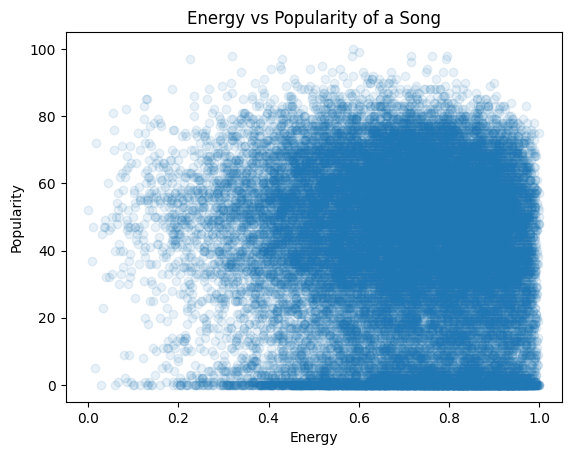

In [6]:
plt.scatter(file['energy'], file['track_popularity'], alpha = 0.1)
plt.xlabel('Energy')
plt.ylabel('Popularity')
plt.title('Energy vs Popularity of a Song')
plt.show()

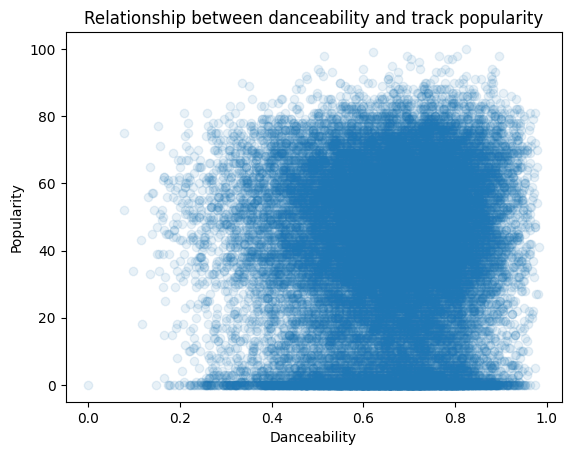

In [7]:
plt.scatter(file['danceability'], file['track_popularity'], alpha = 0.1)
plt.xlabel('Danceability')
plt.ylabel('Popularity')
plt.title('Relationship between danceability and track popularity')
plt.show()

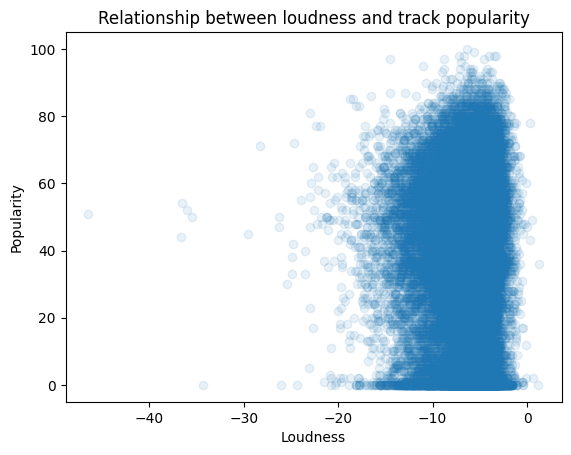

In [8]:
plt.scatter(file['loudness'], file['track_popularity'], alpha = 0.1)
plt.xlabel('Loudness')
plt.ylabel('Popularity')
plt.title('Relationship between loudness and track popularity')
plt.show()

Although the scatter plots have been successfully created, it is still difficult to determine the exact type of correlation of each acoustic feature with the popularity of a track. This means that while each feature may influence popularity, it doesn't strongly determine it.

Thus, in order to figure out the strongest positive correlation, we move on to the correlation coefficient.

In [9]:
corr = file[['track_popularity','energy','danceability','loudness']].corr()['track_popularity']
corr = corr.drop('track_popularity')
corr

,track_popularity
energy,-0.103511
danceability,0.046574
loudness,0.037337


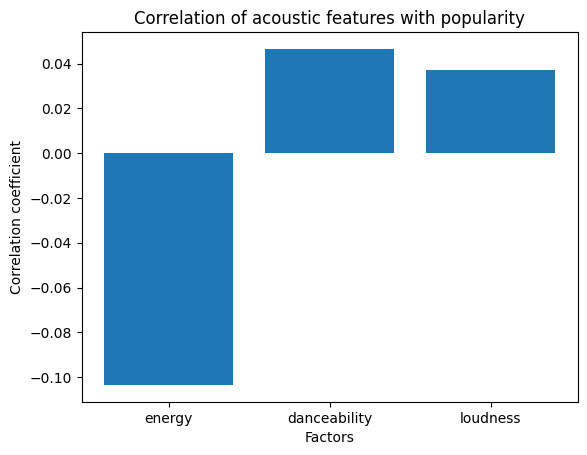

In [10]:
plt.bar(corr.index, corr.values)
plt.xlabel('Factors')
plt.ylabel('Correlation coefficient')
plt.title('Correlation of acoustic features with popularity')
plt.show()

From above matrix and bar graph, we can deduce that danceability has the closest positive correlation with track popularity (0.04), with loudness following close by (0.03). On the other hand, energy has a negative correlation (-0.10). Despite this, the correlation is very small.

### 2. Does the distribution of energy significantly differ across various music genres, and which genres have the most outliers?

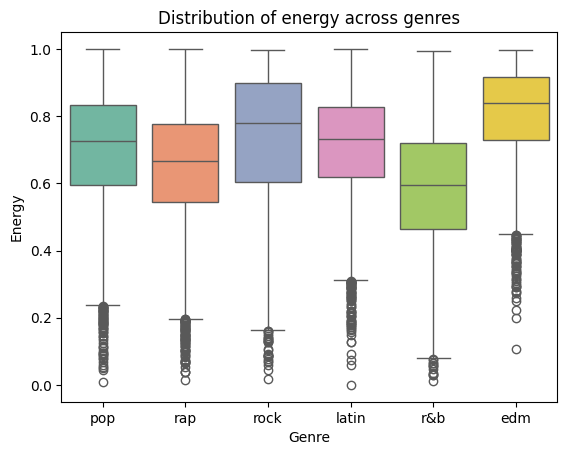

In [11]:
sns.boxplot(x = file['playlist_genre'], y = file['energy'], hue = file['playlist_genre'], palette = 'Set2', legend = False)
plt.title('Distribution of energy across genres')
plt.xlabel('Genre')
plt.ylabel('Energy')
plt.show()

From the above boxplot, we can figure out the following:
1. R&B shows long whiskers as compared to other genres, indicating a wider spread of typical energy values.
2. EDM shows consistent high energy levels, although a few lower-energy outlier tracks are present.
3. Rock and EDM genres show the highest median energy levels, whereas R&B has the lowest median energy.
4. Multiple outliers are present across each genre, suggesting that some tracks deviate from the genre’s overall energy distribution.


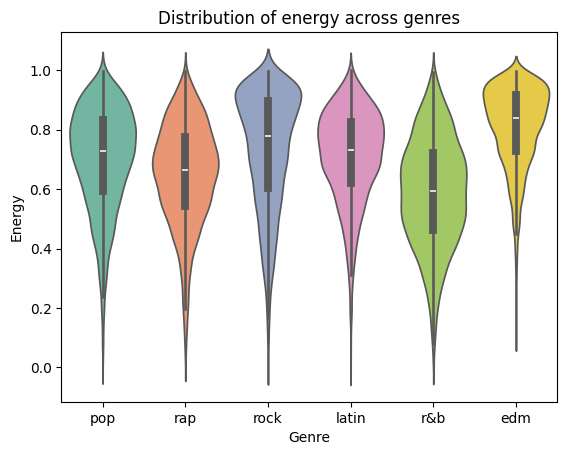

In [12]:
sns.violinplot(x = file['playlist_genre'], y = file['energy'], hue = file['playlist_genre'], palette = 'Set2', legend = False)
plt.title('Distribution of energy across genres')
plt.xlabel('Genre')
plt.ylabel('Energy')
plt.show()

From the above violin plot, the observations are:
1. EDM songs are highly concentrated around high energy levels
2. R&B songs tend to concentrate around medium energy levels
3. Latin songs concentrate around medium to high energy levels similar to pop which is more smoother as compared to Latin
4. Rock songs tend to maintain high energy levels, although they do show variation
5. Rap songs concentrate around moderate energy levels, and are more spread out

Thus, the distribution of energy levels across certain different genres does differ significantly. For example, the distribution of EDM differs very significantly from that of rap, with EDM concentrated along higher levels and rap being fairly spread out. Similarly, rock differes significantly from R&B.

The genres with the highest number of outliers are EDM, Latin, and Pop, indicating that there are quite a number of tracks which differ from the typical energy distribution.

### 3. Do songs with different energy levels show different average popularity?

In [13]:
# Function to categorise energy levels
def energy_level(x):
  if x < 0.4:
    return 'Low Energy'
  elif x < 0.7:
    return 'Medium Energy'
  else:
    return 'High Energy'

In [14]:
file['energy_category'] = file['energy'].apply(energy_level) #Applying the function to energy column
avg_popularity = file.groupby('energy_category')['track_popularity'].mean()

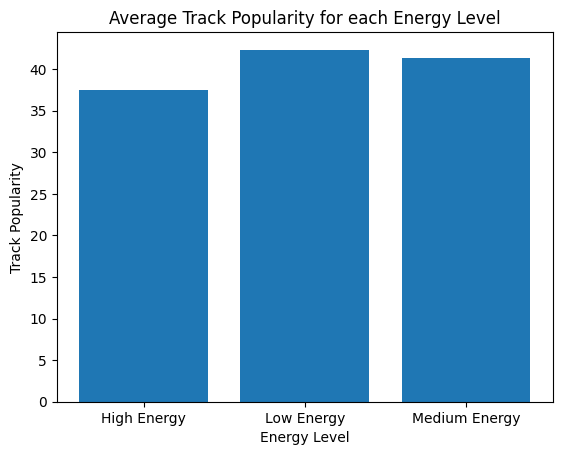

In [15]:
plt.bar(avg_popularity.index, avg_popularity.values)
plt.xlabel('Energy Level')
plt.ylabel('Track Popularity')
plt.title('Average Track Popularity for each Energy Level')
plt.show()

Energy levels do not seem to significantly affect track popularity as the average popularity across different energy levels remains similar.

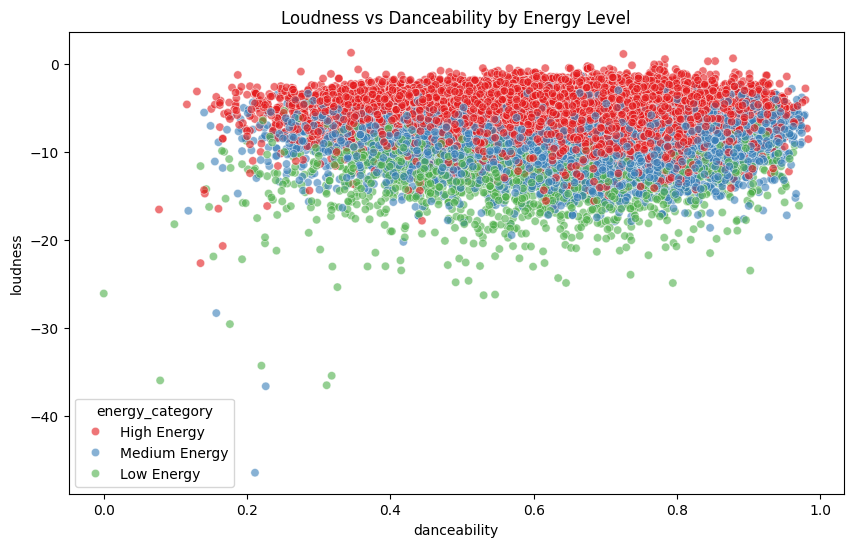

In [16]:
plt.figure(figsize = (10,6))
sns.scatterplot(data=file, x='danceability', y='loudness', hue='energy_category', palette='Set1', alpha=0.6)

plt.title('Loudness vs Danceability by Energy Level')
plt.show()

The scatter plot shows a noticeable relationship between energy level and loudness, with high-energy songs generally appearing at higher loudness values and low-energy songs concentrated at lower loudness levels. However, danceability appears distributed across all energy tiers.

This means that high energy tracks tend to be loud and low energy songs tend to be quieter. On the other hand, a track can be danceable regardless of whether it is low energy or high energy.

### **Conclusion:**
Based on the correlation matrix and the distribution plots, we can conclude the following:
1. Energy, Danceability and Loudness do not significantly influence track popularity, with energy even having a slight negative correlation (-0.10). This indicates that no single acoustic feature can strongly determine popularity.
2. The distribution of energy noticeably differed across genres. EDM and Rock tracks tended to contain higher energy levels, while R&B songs generally showed lower energy distributions.
3. Categorizing songs into energy tiers showed only small differences in average popularity, reinforcing the idea that energy alone is not a major determinant of a song's popularity.
4. The multivariable scatter plot demonstrated a clearer relationship between energy and loudness than between energy and danceability.
